## ATSEviz: Visualizing Alternative Splicing Events
This notebook demonstrates how to use the ATSEviz module from LeafletFA-utils to visualize alternative splicing events.

In [1]:
# Import necessary libraries
import pandas as pd
import os
import sys

# Add main path to sys.path
module_path = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [2]:
db_file = "/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250401_150841/annotation.db"
db = gffutils.FeatureDB(db_file, keep_order=True)

In [3]:
# Visualize random ATSEs
p=pd.read_csv("/gpfs/commons/home/kisaev/LeafletFA-utils/examples/LeafletFA_ATSE_mapper_output_20250402_085738/atse_events_20250402-090324.tsv.gz", sep="\t")
atse_event = p.sample(1)["event_id"].values[0]

# Create a copy of the subset to avoid SettingWithCopyWarning
juncs = p[p["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)
splice_junctions

[{'chrom': 'chr13',
  'start': 58392476,
  'end': 58393195,
  'name': 'junction_1',
  'strand': '-',
  'usage_ratio': 0.5532879818594104},
 {'chrom': 'chr13',
  'start': 58392416,
  'end': 58393195,
  'name': 'junction_2',
  'strand': '-',
  'usage_ratio': 0.4467120181405896}]

In [4]:
# Extract unique transcript IDs from junction_labels
unique_transcripts = pd.Series([t for ts in juncs['transcripts'] for t in ts.split(',')]).unique()

                      transcript_name  transcript_type          transcript_id
ENSMUST00000224182.1       Hnrnpk-224   protein_coding   ENSMUST00000224182.1
ENSMUST00000225674.1       Hnrnpk-232   protein_coding   ENSMUST00000225674.1
ENSMUST00000116403.8       Hnrnpk-202   protein_coding   ENSMUST00000116403.8
ENSMUST00000043269.13      Hnrnpk-201   protein_coding  ENSMUST00000043269.13
ENSMUST00000177019.7       Hnrnpk-216   protein_coding   ENSMUST00000177019.7
ENSMUST00000224531.1       Hnrnpk-227  retained_intron   ENSMUST00000224531.1
ENSMUST00000176359.1       Hnrnpk-209  retained_intron   ENSMUST00000176359.1
ENSMUST00000177497.7       Hnrnpk-221   protein_coding   ENSMUST00000177497.7
ENSMUST00000176257.7       Hnrnpk-206  retained_intron   ENSMUST00000176257.7
ENSMUST00000176797.7       Hnrnpk-213   protein_coding   ENSMUST00000176797.7
ENSMUST00000226015.1       Hnrnpk-234  retained_intron   ENSMUST00000226015.1
ENSMUST00000176207.7       Hnrnpk-205   protein_coding   ENSMUST

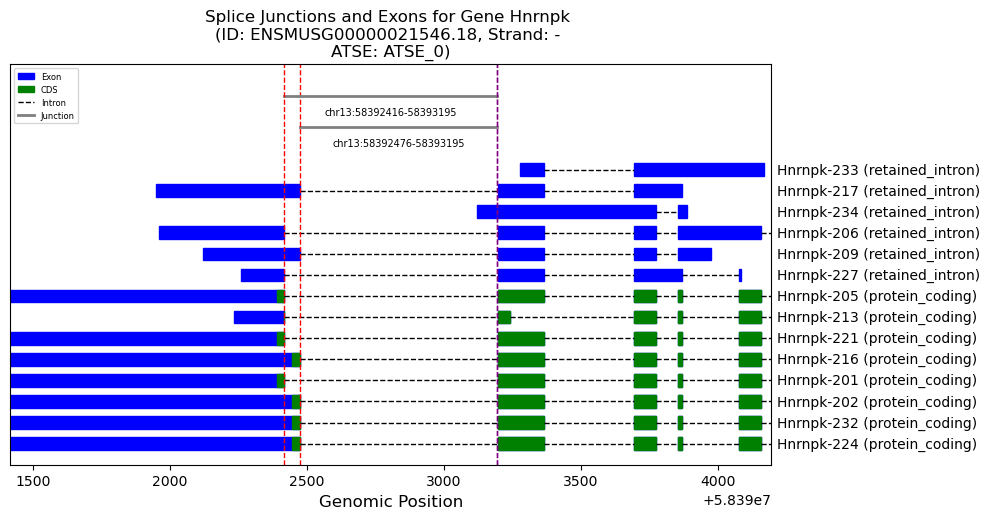

In [5]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = fetch_transcripts_and_annotations(db, unique_transcripts)

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=10, trans_height=0.3, show_usage=False, show_junc_lines=True, filename="test.pdf")

In [6]:
def check_junction_annotation(splice_junctions, db, tolerance=1):
    junction_labels = []
    for junction in tqdm(splice_junctions):
        chrom = junction["chrom"]
        start = junction["start"]
        end = junction["end"]
        strand = junction.get("strand", "+")
        label_5_prime, label_3_prime = "unannotated on 5'", "unannotated on 3'"
        position_off_5_prime, position_off_3_prime = None, None

        transcripts = list(
            db.region(
                region=(chrom, start - 1000, end + 1000), featuretype="transcript"
            )
        )

        # Initialize an empty set for transcript IDs to avoid duplicates
        transcripts_junc = set()

        for transcript in transcripts:
            exons = list(db.children(transcript, featuretype="exon", order_by="start"))

            if strand == "+":
                for exon in exons:
                    if abs(exon.end - start) <= tolerance:
                        label_5_prime = "annotated on 5'"
                        position_off_5_prime = exon.end - start
                        transcripts_junc.add(transcript.id)
                        break
                for exon in exons:
                    if abs(exon.start - end) <= tolerance:
                        label_3_prime = "annotated on 3'"
                        position_off_3_prime = exon.start - end
                        break
            elif strand == "-":
                for exon in exons:
                    if abs(exon.start - end) <= tolerance:
                        label_5_prime = "annotated on 5'"
                        position_off_5_prime = exon.start - end
                        transcripts_junc.add(transcript.id)
                        break
                for exon in exons:
                    if abs(exon.end - start) <= tolerance:
                        label_3_prime = "annotated on 3'"
                        position_off_3_prime = exon.end - start
                        transcripts_junc.add(transcript.id)
                        break

        junction_labels.append(
            {
                "junction": f"{chrom}:{start}-{end}",
                "strand": strand,
                "label_5_prime": label_5_prime,
                "label_3_prime": label_3_prime,
                "position_off_5_prime": position_off_5_prime,
                "position_off_3_prime": position_off_3_prime,
                "transcripts": list(transcripts_junc),
            }
        )
    return junction_labels

In [7]:
check_junction_annotation(splice_junctions, db, tolerance=1)

100%|██████████| 2/2 [00:00<00:00,  7.05it/s]


[{'junction': 'chr13:58392476-58393195',
  'strand': '-',
  'label_5_prime': "annotated on 5'",
  'label_3_prime': "annotated on 3'",
  'position_off_5_prime': 1,
  'position_off_3_prime': 0,
  'transcripts': ['ENSMUST00000043269.13',
   'ENSMUST00000177051.7',
   'ENSMUST00000224182.1',
   'ENSMUST00000176359.1',
   'ENSMUST00000224531.1',
   'ENSMUST00000116403.8',
   'ENSMUST00000177497.7',
   'ENSMUST00000176257.7',
   'ENSMUST00000176207.7',
   'ENSMUST00000176797.7',
   'ENSMUST00000177019.7',
   'ENSMUST00000225674.1']},
 {'junction': 'chr13:58392416-58393195',
  'strand': '-',
  'label_5_prime': "annotated on 5'",
  'label_3_prime': "annotated on 3'",
  'position_off_5_prime': 1,
  'position_off_3_prime': 0,
  'transcripts': ['ENSMUST00000043269.13',
   'ENSMUST00000177051.7',
   'ENSMUST00000224182.1',
   'ENSMUST00000176359.1',
   'ENSMUST00000224531.1',
   'ENSMUST00000116403.8',
   'ENSMUST00000177497.7',
   'ENSMUST00000176257.7',
   'ENSMUST00000176207.7',
   'ENSMUST0000

In [8]:
juncs.iloc[0]["both_ends_transcripts"]

'ENSMUST00000224182.1,ENSMUST00000225674.1,ENSMUST00000116403.8,ENSMUST00000043269.13,ENSMUST00000177019.7,ENSMUST00000224531.1,ENSMUST00000176359.1,ENSMUST00000177497.7,ENSMUST00000176257.7,ENSMUST00000176797.7,ENSMUST00000176207.7,ENSMUST00000177051.7'

In [9]:
juncs.iloc[0]

event_id                                                               ATSE_0
gene_id                                                 ENSMUSG00000021546.18
gene_name                                                              Hnrnpk
gene_types                                                     protein_coding
transcripts                 ENSMUST00000224182.1,ENSMUST00000225674.1,ENSM...
both_ends_transcripts       ENSMUST00000224182.1,ENSMUST00000225674.1,ENSM...
only_5_prime_transcripts            ENSMUST00000226015.1,ENSMUST00000225866.1
only_3_prime_transcripts                                                  NaN
transcript_types                               retained_intron,protein_coding
num_junctions                                                               2
event_type                                                alternative_3_prime
annotation_status                                                 unannotated
junction_id                                         chr13_583924